<a href="https://colab.research.google.com/github/DataCommanderUsher/Titanic---Machine-Learning-from-Disaster/blob/main/Titanic_Machine_Learning_from_Disaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* **Author**: Usher Dube
* **Date**: 6 Dec 2025, 01:00
* **Descritption**: We are working on a begineer ML project from kaggle called Titanic - Machine Learning from Disaster
* **Link**: https://www.kaggle.com/competitions/titanic/data

In [60]:
#All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [24]:
#Read our train dataset, NAN on cabin
github_csv_url = 'https://raw.githubusercontent.com/DataCommanderUsher/Titanic---Machine-Learning-from-Disaster/main/train.csv'
train_df = pd.read_csv(github_csv_url)
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
#Noticed NAN for age and its in float not integer
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [26]:
train_df.shape

(891, 12)

In [27]:
#Age has missing values, 714/891
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Considering the fact that man had to ensure safety of woman and children, it makes sense why most survived than man. That is shown by the stats below

In [28]:
survival_rate_by_sex = train_df.groupby('Sex')['Survived'].mean().reset_index()
print(survival_rate_by_sex)

      Sex  Survived
0  female  0.742038
1    male  0.188908


/tmp/ipython-input-3161079370.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=survival_rate_by_sex, palette='viridis')


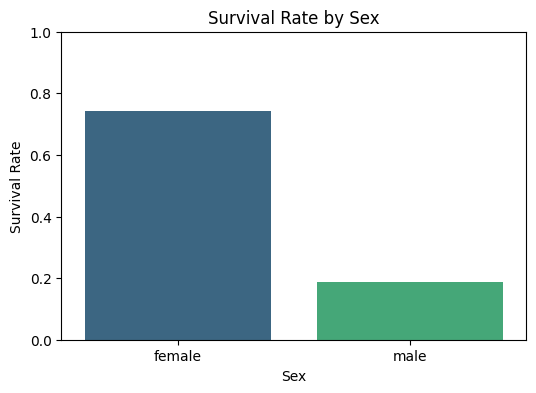

In [29]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=survival_rate_by_sex, palette='viridis')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

It appears more first-class people managed to survive compared to other classes

In [30]:
survival_rate_by_pclass = train_df.groupby('Pclass')['Survived'].mean().reset_index()
print(survival_rate_by_pclass)

   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363


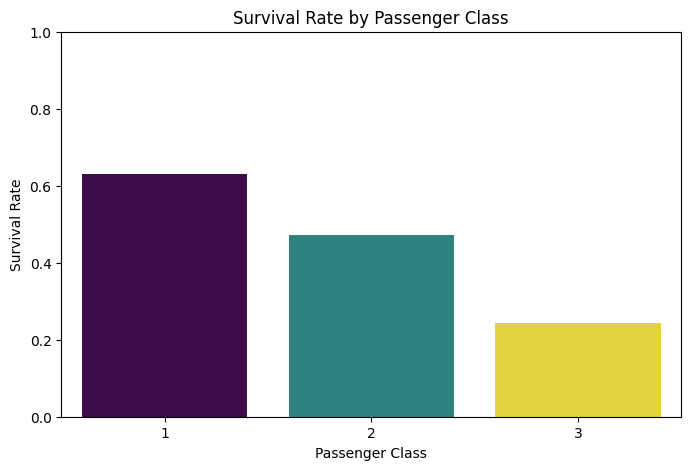

In [31]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=survival_rate_by_pclass, palette='viridis', hue='Pclass', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Set y-axis limit to represent proportion/rate
plt.show()

In [32]:
#Replace NAN for age with median and turn into an integer
train_df['Age'] = train_df['Age'].astype(int)
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)

/tmp/ipython-input-3837728605.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)


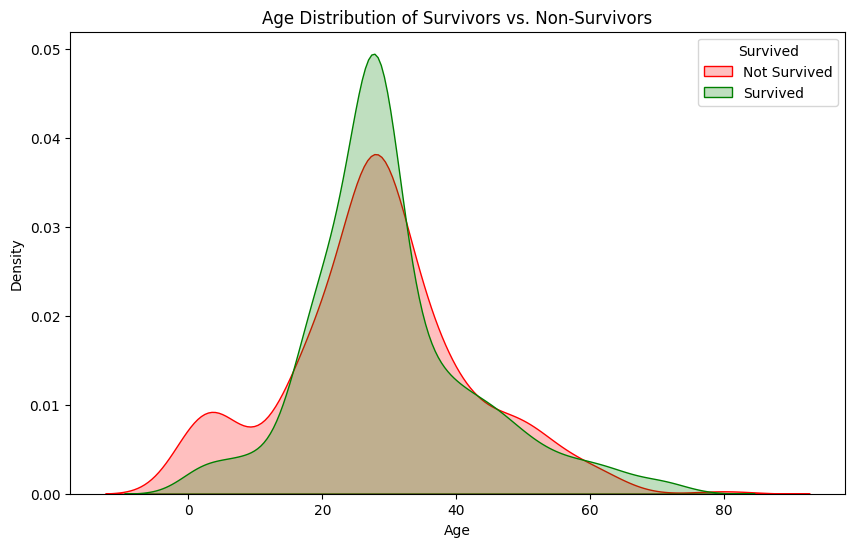

In [33]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train_df, x='Age', hue='Survived', fill=True, common_norm=False, palette={0: 'green', 1: 'red'})
plt.title('Age Distribution of Survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Survived', labels=['Not Survived', 'Survived'])
plt.show()

In [34]:
#Replace the two missing values in embarked with the mode
most_frequent_embarked = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(most_frequent_embarked)

In [35]:
survival_rate_by_embarked = train_df.groupby('Embarked')['Survived'].mean().reset_index()
print(survival_rate_by_embarked)

  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009


In [47]:
#Check missing data
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [48]:
#drop cabin column as it has 687/891 missing values
train_df.drop('Cabin', axis=1, inplace=True)

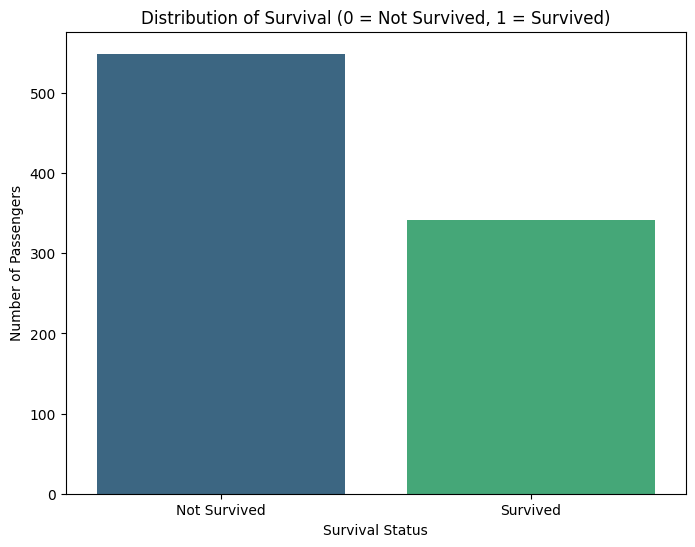

In [49]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=train_df, palette='viridis', hue='Survived', legend=False)
plt.title('Distribution of Survival')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Not Survived', 'Survived'])
plt.show()

In [51]:
# Make a copy of the dataframe to avoid modifying the original during this step
df_oversample = train_df.copy()

# Drop irrelevant columns for initial model training that we've already processed or decided to drop
df_oversample = df_oversample.drop(columns=['PassengerId', 'Name', 'Ticket', 'Fare', 'SibSp', 'Parch'])

# Convert categorical features to numerical using one-hot encoding
df_oversample = pd.get_dummies(df_oversample, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)

# Separate features (X) and target (y)
X = df_oversample.drop('Survived', axis=1)
y = df_oversample['Survived']

Features (X) shape before oversampling: (891, 8)
Target (y) distribution before oversampling:
 Survived
0    549
1    342
Name: count, dtype: int64


In [52]:
# Initialize RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Apply oversampling to the dataset
X_resampled, y_resampled = ros.fit_resample(X, y)

y_resampled.value_counts()

Features (X) shape after oversampling: (1098, 8)
Target (y) distribution after oversampling:
 Survived
0    549
1    549
Name: count, dtype: int64


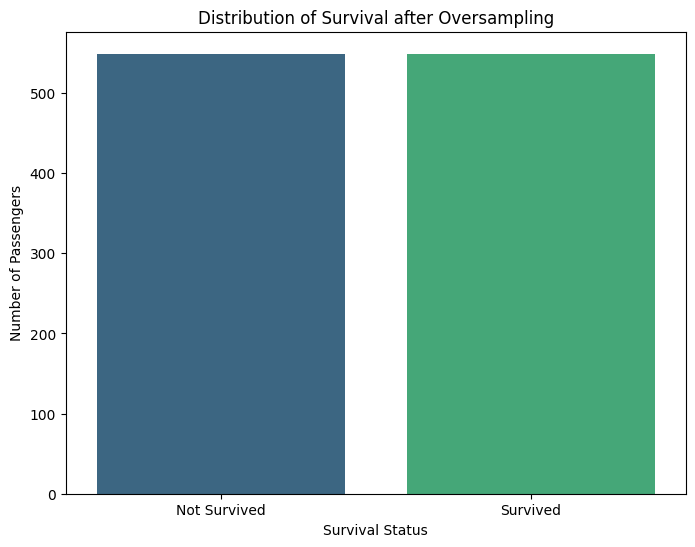

In [53]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled, palette='viridis', hue=y_resampled, legend=False)
plt.title('Distribution of Survival after Oversampling')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Not Survived', 'Survived'])
plt.show()

In [54]:
# Split the oversampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

X_train shape: (878, 8)
X_test shape: (220, 8)
y_train shape: (878,)
y_test shape: (220,)


In [55]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for better convergence with small datasets
model.fit(X_train, y_train)

Logistic Regression model trained successfully.


In [56]:
y_pred = model.predict(X_test)

Predictions on the test set generated successfully.


**Reasoning**:
Now that predictions have been made on the test set, the next step is to evaluate the model's performance by calculating its accuracy and generating a confusion matrix. This requires importing `accuracy_score` and `confusion_matrix` from `sklearn.metrics`.



79.54545454545455


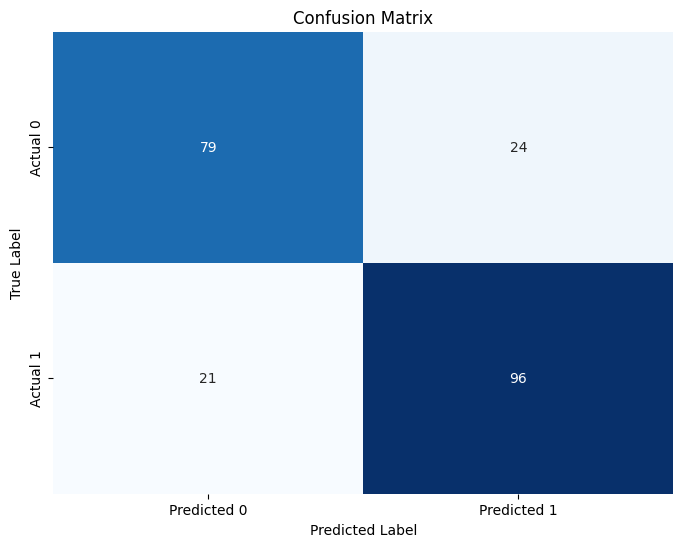

In [66]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(accuracy * 100)

# Generate and visualize confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [67]:
#Using test dataset
github_test_csv_url = 'https://raw.githubusercontent.com/DataCommanderUsher/Titanic---Machine-Learning-from-Disaster/main/test.csv'
test_df = pd.read_csv(github_test_csv_url)
passenger_ids = test_df['PassengerId']
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [68]:
test_df['Age'].fillna(28.0, inplace=True)
test_df['Age'] = test_df['Age'].astype(int)

test_df['Fare'].fillna(14.4542, inplace=True)

test_df['Embarked'].fillna('S', inplace=True)

Missing values handled for 'Age', 'Fare', and 'Embarked' in test_df.


/tmp/ipython-input-2003760529.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Age'].fillna(28.0, inplace=True)
/tmp/ipython-input-2003760529.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [70]:
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

'FamilySize' column created in test_df.


In [71]:
fare_bins = pd.qcut(train_df['Fare'], q=4, labels=False, retbins=True)[1]
test_df['Fare_Bin'] = pd.cut(test_df['Fare'], bins=fare_bins, labels=[0, 1, 2, 3], include_lowest=True)

'Fare_Bin' column created in test_df.


In [72]:
test_df.drop(columns=['Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], inplace=True)

Dropped 'Name', 'Ticket', 'Cabin', 'SibSp', and 'Parch' columns from test_df.


In [73]:
test_df = pd.get_dummies(test_df, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)

Categorical features 'Sex', 'Embarked', and 'Pclass' converted to numerical using one-hot encoding.


In [74]:
test_df = test_df.drop('PassengerId', axis=1)

# Ensure columns match training data, filling missing ones with 0
# Use X_resampled's columns as the reference for features
train_cols = X_resampled.columns
missing_cols = set(train_cols) - set(test_df.columns)
for c in missing_cols:
    test_df[c] = 0

# Reorder test_df columns to match train_df features
test_df = test_df[train_cols]

Test DataFrame columns aligned with training features.


In [75]:
test_predictions = model.predict(test_df)

Predictions on the test dataset generated successfully.


In [76]:
submission_df = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': test_predictions})

Submission DataFrame created.


**Reasoning**:
Following the creation of the submission DataFrame, I will save it to an Excel file named `titanic_predictions.xlsx`, ensuring the index is not included, as specified in the instructions.



In [77]:
submission_df.to_excel('titanic_predictions.xlsx', index=False)

Submission file 'titanic_predictions.xlsx' created successfully.
